In [1]:
#importing libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
#reading CSV file
df = pd.read_csv('Country-data.csv')

In [3]:
#showing top 5 rows
df.head()


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [7]:
#checking datatypes
df.dtypes

country        object
child_mort    float64
exports       float64
health        float64
imports       float64
income          int64
inflation     float64
life_expec    float64
total_fer     float64
gdpp            int64
dtype: object

In [9]:
#checking null values
df.isnull().sum()

country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

In [11]:
#checking duplicates
print ("Number of duplicate records : ",df.duplicated().sum())

Number of duplicate records :  0


In [13]:
#create duplicate df
dfa = df.copy()

In [15]:
#Create df with only numbers
dfn = df.select_dtypes(include='number')

In [17]:
dfn.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


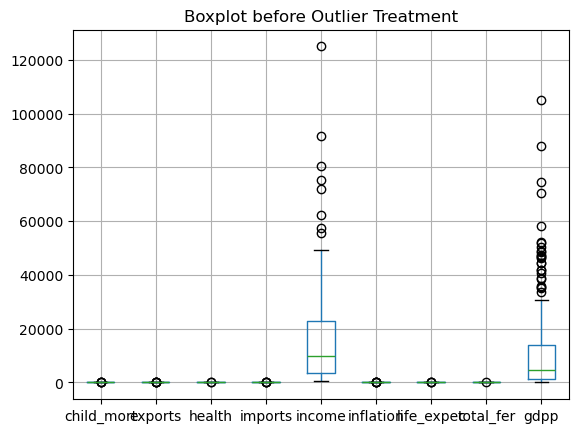

In [19]:
dfa.boxplot()
plt.title("Boxplot before Outlier Treatment")
plt.show()

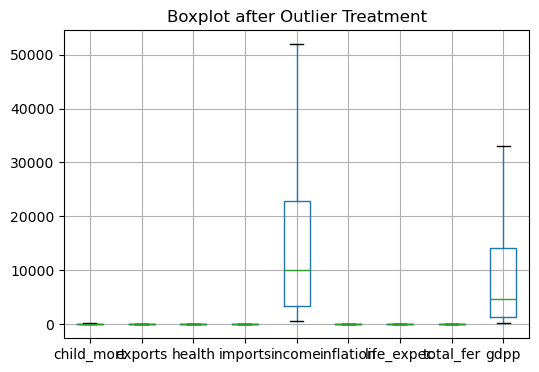

In [21]:
#removing outliers
def remove_outlier(col):
    Q1, Q3 = col.quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower_range = Q1 - (1.5 * IQR)
    upper_range = Q3 + (1.5 * IQR)
    return lower_range, upper_range

for i in dfn:
    LL, UL = remove_outlier(dfn[i])
    dfn[i] = np.where(dfn[i] > UL, UL, dfn[i])
    dfn[i] = np.where(dfn[i] < LL, LL, dfn[i])

dfn.boxplot(figsize=(6,4))
plt.title("Boxplot after Outlier Treatment")
plt.show()

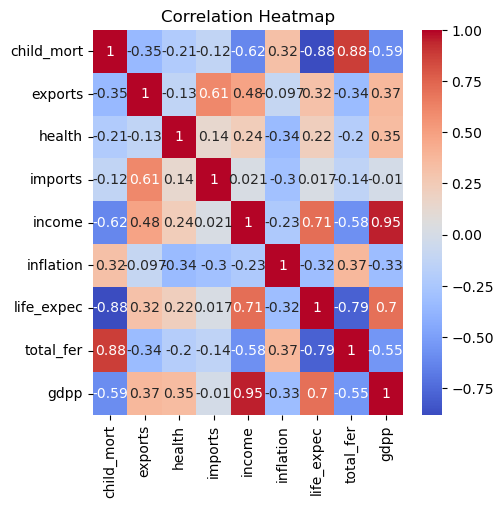

In [23]:
#checking correlation using heatmap
plt.figure(figsize=(5,5))
sns.heatmap(dfn.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

## Scaling data

In [26]:
from sklearn.preprocessing import StandardScaler

In [37]:
scaler = StandardScaler()
scaled_df = pd.DataFrame(scaler.fit_transform(dfn),columns=dfn.columns)

## Principal Component Analysis

In [40]:
from sklearn.decomposition import PCA

In [42]:
#Defining number of PCs to Generate
n=scaled_df.shape[1]

#Finding PCs for data
pca = PCA(n_components=n, random_state=1)
data_pca1 = pd.DataFrame(pca.fit_transform(scaled_df))

#The percentage of variance explained by each PC
exp_var = pca.explained_variance_ratio_

In [44]:
scaled_df.shape[1]

9

In [46]:
scaled_df.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,1.369802,-1.391107,0.296013,-0.047444,-0.943936,0.355270,-1.702225,1.915276,-0.846341
1,-0.550464,-0.543547,-0.091190,0.135021,-0.395181,-0.385208,0.663321,-0.862779,-0.540827
2,-0.271295,-0.053846,-0.985893,-0.713196,-0.199291,1.351551,0.686859,-0.036691,-0.508868
3,2.121210,1.071524,-1.482114,-0.146074,-0.660984,2.293979,-1.243238,2.141784,-0.589198
4,-0.714835,0.280469,-0.286671,0.642965,0.209637,-0.841463,0.722166,-0.543003,0.159686


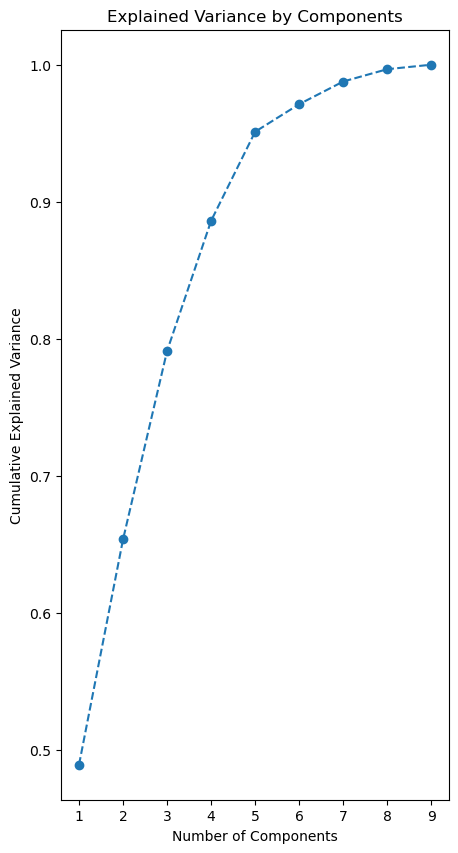

In [48]:
#Visualise Explained Variance by individual components
plt.figure(figsize=(5,10))
plt.plot(range(1,len(exp_var)+1),exp_var.cumsum(),marker='o',linestyle='--')
plt.title("Explained Variance by Components")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.show()

In [58]:
#Extracting Principle Components 
pc_comps = ['PC1','PC2','PC3','PC4','PC5']
data_pca = pd.DataFrame(np.round(pca.components_[:5,],2),index=pc_comps,columns=scaled_df.columns)
data_pca.T

,PC1,PC2,PC3,PC4,PC5
child_mort,-0.42,0.07,0.08,0.39,-0.22
exports,0.24,0.59,-0.32,0.21,0.01
health,0.17,-0.15,0.68,0.31,0.54
imports,0.10,0.74,0.22,-0.02,0.21
income,0.41,-0.10,-0.18,0.45,-0.15
inflation,-0.22,-0.12,-0.58,0.21,0.72
life_expec,0.43,-0.16,-0.11,-0.21,0.08
total_fer,-0.40,0.04,0.05,0.44,-0.14
gdpp,0.41,-0.16,-0.04,0.47,-0.19


## Heirarchical Clustering

In [60]:
from scipy.cluster.hierarchy import dendrogram, linkage

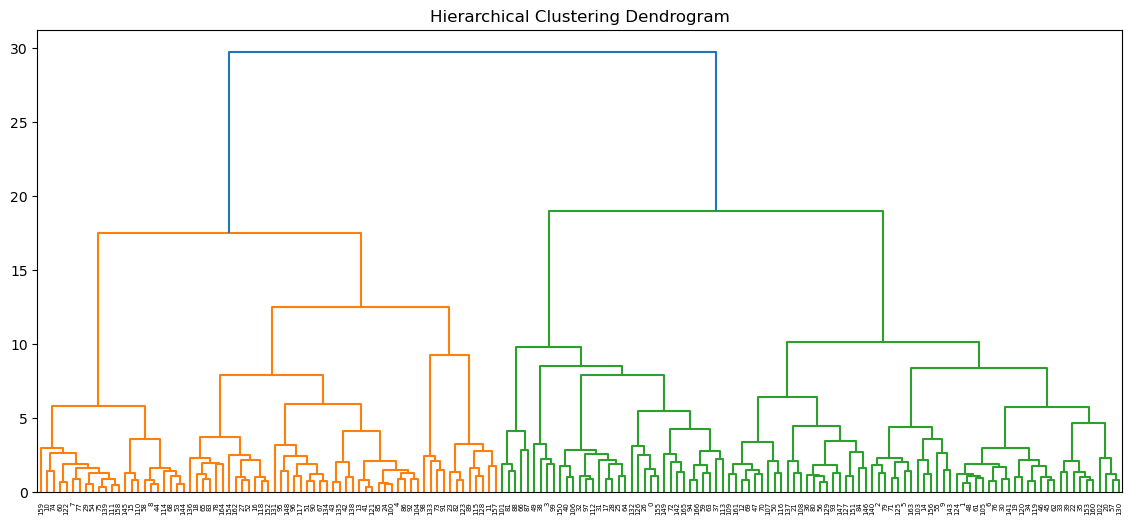

In [62]:

wardlink = linkage(scaled_df, method = 'ward')
plt.figure(figsize=(14, 6))
dend = dendrogram(wardlink)

plt.title("Hierarchical Clustering Dendrogram")
plt.show()

In [64]:
from scipy.cluster.hierarchy import fcluster

In [66]:
cluster = fcluster(wardlink,2,criterion='maxclust')

In [68]:
dfa['cluster_no'] = cluster
dfa.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,cluster_no
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,2
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,2
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,2
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,2
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,1


## KMeans - Clustering

In [88]:
from sklearn.cluster import KMeans

C:\Users\BHUVI\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\BHUVI\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\BHUVI\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\BHUVI\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Window

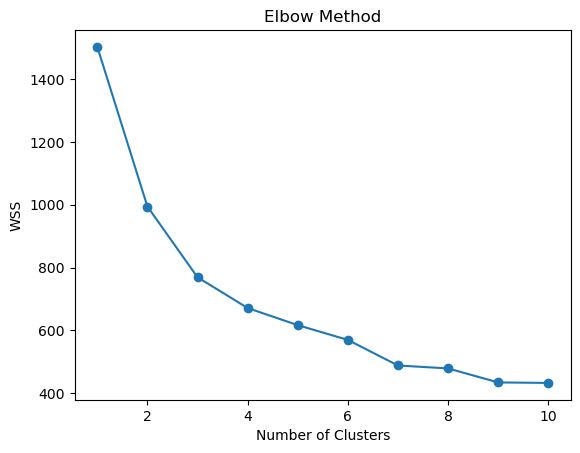

In [90]:
#checking how many clusters to be set
wss=[]
for i in range(1, 11):
    KM = KMeans(n_clusters=i)  
    KM.fit(scaled_df)
    wss.append(KM.inertia_)

plt.plot(range(1, 11), wss, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('WSS')
plt.title('Elbow Method')
plt.show()

In [92]:
#assigning clusters
k_means = KMeans(n_clusters=2,random_state=12,n_init=10)
k_means.fit(scaled_df)
labels = k_means.labels_

C:\Users\BHUVI\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [94]:
dfa["clus_kmeans"] = labels
dfa.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,cluster_no,clus_kmeans
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,2,0
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,2,1
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,2,1
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,2,0
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,1,1


In [102]:
from sklearn.metrics import silhouette_samples,silhouette_score, calinski_harabasz_score, davies_bouldin_score

In [104]:
print ("Silhouette max value",silhouette_samples(scaled_df,labels).max())

Silhouette max value 0.48678987542410823


In [106]:
print ("Silhouette min value",silhouette_samples(scaled_df,labels).min())

Silhouette min value 0.006837269389479201


## Comparative Study 

In [108]:
print("Silhouette Score of Hierarchical Clustering = ",silhouette_score(scaled_df,cluster))
print("Calinski-Harabasz Index:", calinski_harabasz_score(scaled_df,cluster))
print("Davies-Bouldin Index:", davies_bouldin_score(scaled_df,cluster))

cluster_counts = dfa.groupby("cluster_no")['country'].count()
print("\nCountries per Cluster:\n", cluster_counts)

Silhouette Score of Hierarchical Clustering =  0.24574950716044353
Calinski-Harabasz Index: 68.86749594341791
Davies-Bouldin Index: 1.4590446140630011

Countries per Cluster:
 cluster_no
1    71
2    96
Name: country, dtype: int64


In [110]:
print("Silhouette Score of KMeans Clustering = ",silhouette_score(scaled_df,labels))
print("Calinski-Harabasz Index:", calinski_harabasz_score(scaled_df,labels))
print("Davies-Bouldin Index:", davies_bouldin_score(scaled_df,labels))

cluster_counts = dfa.groupby("clus_kmeans")['country'].count()
print("\nCountries per Cluster:\n", cluster_counts)

Silhouette Score of KMeans Clustering =  0.2898395153574449
Calinski-Harabasz Index: 84.69727199551393
Davies-Bouldin Index: 1.3078551887128524

Countries per Cluster:
 clus_kmeans
0    69
1    98
Name: country, dtype: int64
